<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

<b>ESPECIALIZACIÓN EN CIENCIA DE DATOS E INGELIGENCIA ARTIFICIAL</b>

<strong>Fundamentos de Estadística para Ciencia de Datos</strong>

# Sesión 05 — Taller práctico: estadística descriptiva (caso de estudio)

## Objetivos de aprendizaje

Al finalizar este taller serás capaz de:

- Aplicar el flujo completo de estadística descriptiva (tipos de datos, calidad de datos, descriptiva cualitativa y cuantitativa) sobre un caso real, integrando lo visto en las sesiones 1 a 4.
- Tomar y justificar decisiones de limpieza de datos (faltantes, valores imposibles) según el contexto de cada variable.
- Describir variables cualitativas y cuantitativas, y relacionarlas con una variable target de negocio.
- Comunicar hallazgos descriptivos como insumo para decisiones futuras, sin extrapolar más allá de lo que los datos permiten.

> **Nota:** este taller integra las sesiones 1 a 4. No se abordan pruebas de hipótesis ni medidas formales de asociación (Pearson, Chi-cuadrado, Cramér's V, eta-cuadrado) — eso es contenido de la sesión 6 y siguientes.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

pd.set_option("display.precision", 3)

## 1. Planteamiento del caso y carga de datos

**Contexto:** eres analista de datos de una empresa de taxis en Nueva York. El equipo comercial evalúa una campaña para incentivar el pago con tarjeta (mejor trazabilidad, registro real de propinas) y quiere entender primero cómo lucen los viajes de marzo de 2019, y qué diferencia a los pagados en efectivo de los pagados con tarjeta.

**Objetivo del taller:** dejar el dataset `taxis` explorado, limpio y descrito (variables cualitativas y cuantitativas), identificando qué caracteriza a los viajes según el método de pago, como insumo para decisiones posteriores. No se construye ningún modelo ni prueba de hipótesis en este taller.

In [2]:
taxis = sns.load_dataset("taxis")
print(f"Filas: {taxis.shape[0]}, columnas: {taxis.shape[1]}")
taxis.head()

Filas: 6433, columnas: 14


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [3]:
taxis.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


### Clasificación de variables

Antes de describir nada, clasificamos cada columna según la taxonomía de la sesión 1:

| Variable | Tipo | Subtipo |
|---|---|---|
| `pickup`, `dropoff` | Temporal (datetime) | No cae directamente en cualitativa/cuantitativa; de aquí se puede derivar una numérica (duración) o una categórica (día/hora) |
| `passengers` | Cuantitativa | Discreta (conteo) |
| `distance` | Cuantitativa | Continua (razón) |
| `fare`, `tip`, `tolls`, `total` | Cuantitativa | Continua (razón) |
| `color` | Cualitativa | Nominal |
| `payment` | Cualitativa | Nominal — **variable target de este taller** |
| `pickup_zone`, `dropoff_zone` | Cualitativa | Nominal, alta cardinalidad |
| `pickup_borough`, `dropoff_borough` | Cualitativa | Nominal |

## 2. Calidad de datos: faltantes y valores mal capturados

Antes de describir cualquier variable hay que verificar que los datos sean confiables: ¿hay valores faltantes? ¿hay valores que no tienen sentido físico (p. ej. un viaje con 0 pasajeros)? Ignorar esto contamina cualquier estadístico que se calcule después.

In [4]:
taxis.isna().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

`payment` (44 filas), `pickup_zone`/`dropoff_zone` (26/45) y `pickup_borough`/`dropoff_borough` (26/45) tienen faltantes reales. `payment` es justo la variable target de este taller, así que su tratamiento merece especial cuidado.

In [5]:
duracion_min = (taxis["dropoff"] - taxis["pickup"]).dt.total_seconds() / 60

print(f"Viajes con duración <= 0 (llegada antes o igual a la salida): {(duracion_min <= 0).sum()}")
print(f"Viajes con passengers == 0 (imposible, todo viaje tiene al menos un pasajero): {(taxis['passengers'] == 0).sum()}")
print(f"Viajes con distance == 0: {(taxis['distance'] == 0).sum()}")

Viajes con duración <= 0 (llegada antes o igual a la salida): 6
Viajes con passengers == 0 (imposible, todo viaje tiene al menos un pasajero): 96
Viajes con distance == 0: 51


Más allá de los faltantes explícitos (`NaN`), hay valores presentes pero **imposibles o sospechosos**. Cada anomalía se trata distinto, según qué tan defendible es "corregirla":

- **Duración ≤ 0:** error de captura inequívoco (un viaje no puede terminar antes de empezar) y un volumen insignificante → se **eliminan** esas filas.
- **`payment` faltante:** es la variable target de este análisis; no hay forma defendible de adivinar el método de pago de un viaje → se **eliminan** esas filas (< 1% de los datos).
- **Zonas/boroughs faltantes:** no son el foco del análisis y perderlas eliminaría filas útiles para el resto de variables → se **imputan** con una categoría explícita `"Desconocido"`.
- **`passengers == 0`:** imposible físicamente, pero perder esas filas descartaría su `fare`/`distance`/etc. → se trata como faltante y se **imputa con la moda**.
- **`distance == 0` con tarifa > 0:** podría ser un trayecto real muy corto redondeado a cero, no hay evidencia suficiente de que sea un error → se **deja tal cual**, documentando la ambigüedad (no toda anomalía debe "corregirse").

In [6]:
taxis_limpio = taxis.copy()
taxis_limpio["duracion_min"] = duracion_min

n_inicial = len(taxis_limpio)

# 1. Duración <= 0: error de captura inequívoco
taxis_limpio = taxis_limpio[taxis_limpio["duracion_min"] > 0]

# 2. payment faltante: es el target del análisis, no se puede imputar de forma defendible
taxis_limpio = taxis_limpio[taxis_limpio["payment"].notna()]

# 3. Zonas/boroughs faltantes: se preservan las filas con una categoría explícita
columnas_geograficas = ["pickup_zone", "dropoff_zone", "pickup_borough", "dropoff_borough"]
for columna in columnas_geograficas:
    taxis_limpio[columna] = taxis_limpio[columna].astype(object).fillna("Desconocido")

# 4. passengers == 0 es imposible: se trata como faltante y se imputa con la moda
n_passengers_cero = (taxis_limpio["passengers"] == 0).sum()
taxis_limpio.loc[taxis_limpio["passengers"] == 0, "passengers"] = np.nan
moda_passengers = taxis_limpio["passengers"].mode()[0]
taxis_limpio["passengers"] = taxis_limpio["passengers"].fillna(moda_passengers).astype(int)

print(f"Filas iniciales: {n_inicial}")
print(f"Filas finales: {len(taxis_limpio)} ({n_inicial - len(taxis_limpio)} eliminadas)")
print(f"passengers == 0 imputados con la moda ({int(moda_passengers)}): {n_passengers_cero} filas")
print(f"Valores faltantes restantes: {taxis_limpio.isna().sum().sum()}")

Filas iniciales: 6433
Filas finales: 6384 (49 eliminadas)
passengers == 0 imputados con la moda (1): 90 filas
Valores faltantes restantes: 0


## 3. Descriptiva de variables cualitativas

Con los datos limpios, empezamos por las variables categóricas: `payment` (nuestro target), `color` y las variables geográficas.

In [7]:
tabla_payment = taxis_limpio["payment"].value_counts().to_frame(name="FA")
tabla_payment["FR"] = tabla_payment["FA"] / len(taxis_limpio)
tabla_payment["Porcentaje (%)"] = tabla_payment["FR"] * 100
tabla_payment

,FA,FR,Porcentaje (%)
payment,,,
credit card,4574,0.716,71.648
cash,1810,0.284,28.352


In [8]:
tabla_color = taxis_limpio["color"].value_counts().to_frame(name="FA")
tabla_color["FR"] = tabla_color["FA"] / len(taxis_limpio)
tabla_color["Porcentaje (%)"] = tabla_color["FR"] * 100
tabla_color

,FA,FR,Porcentaje (%)
color,,,
yellow,5412,0.848,84.774
green,972,0.152,15.226


La gran mayoría de los viajes se paga con tarjeta (~72%) y se hace en taxis amarillos (~85%) — los taxis verdes (*boro taxis*) solo pueden operar fuera del centro de Manhattan, lo que ya anticipa una posible relación con `pickup_borough`.

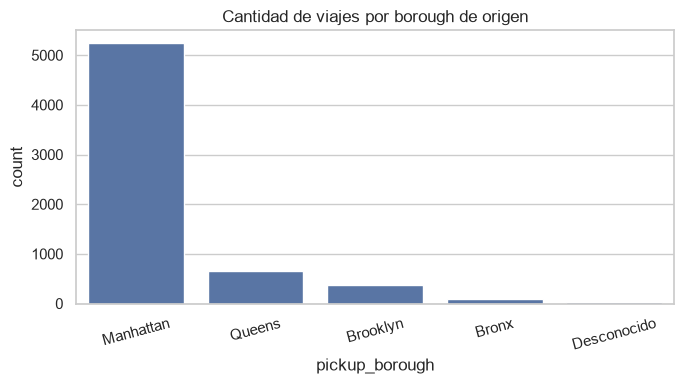

In [9]:
orden_borough = taxis_limpio["pickup_borough"].value_counts().index

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=taxis_limpio, x="pickup_borough", order=orden_borough, ax=ax)
ax.set_title("Cantidad de viajes por borough de origen")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Manhattan concentra la enorme mayoría de los viajes. `pickup_zone`/`dropoff_zone` tienen mucha más granularidad (194 y 203 zonas distintas) — la misma alta cardinalidad que vimos en la sesión 4 con `manufacturer`. Se dejan fuera del resto del análisis; agregarlas a top-N + "Otros" queda como posible extensión.

In [10]:
tabla_contingencia = pd.crosstab(taxis_limpio["pickup_borough"], taxis_limpio["payment"], normalize="index") * 100
tabla_contingencia

payment,cash,credit card
pickup_borough,,
Bronx,25.253,74.747
Brooklyn,31.135,68.865
Desconocido,19.048,80.952
Manhattan,26.681,73.319
Queens,40.986,59.014


Queens destaca con la mayor proporción de pagos en efectivo (~41%, frente a ~25-31% en el resto): un buen candidato a investigar para la campaña de pago con tarjeta.

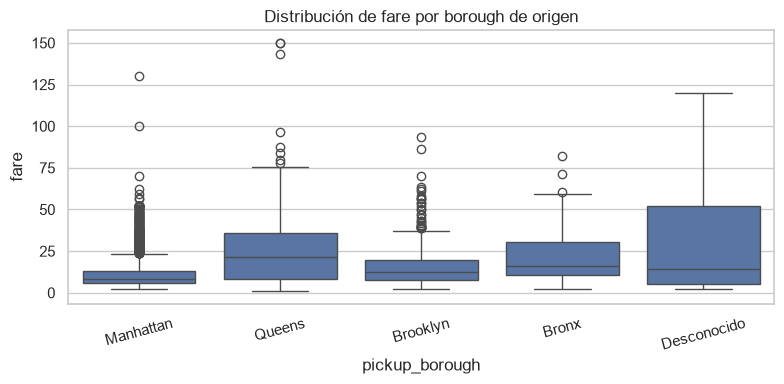

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=taxis_limpio, x="pickup_borough", y="fare", order=orden_borough, ax=ax)
ax.set_title("Distribución de fare por borough de origen")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Queens tiene la tarifa mediana más alta (~$21.5) y Manhattan la más baja (~$8.5) — consistente con que los aeropuertos JFK y LaGuardia están en Queens, generando viajes más largos y caros.

## 4. Descriptiva de variables cuantitativas

Usamos `fare` como variable "hilo conductor" de esta sección (igual que `horsepower` en las sesiones 2 y 3), y retomamos `distance`/`total` puntualmente.

In [12]:
fare = taxis_limpio["fare"]
fare.describe()

count    6384.000
mean       13.104
std        11.540
min         1.000
25%         6.500
50%         9.500
75%        15.000
max       150.000
Name: fare, dtype: float64

In [13]:
media = fare.mean()
mediana = fare.median()
std_dev = fare.std(ddof=1)
cv = std_dev / media * 100
q1, q3 = fare.quantile([0.25, 0.75])
iqr = q3 - q1

print(f"Media: ${media:.2f}")
print(f"Mediana: ${mediana:.2f}")
print(f"Desviación estándar: ${std_dev:.2f}")
print(f"Coeficiente de variación: {cv:.1f}%")
print(f"Q1: ${q1:.2f}, Q3: ${q3:.2f}, IQR: ${iqr:.2f}")

Media: $13.10
Mediana: $9.50
Desviación estándar: $11.54
Coeficiente de variación: 88.1%
Q1: $6.50, Q3: $15.00, IQR: $8.50


La media (\$13.10) es mayor que la mediana (\$9.50): igual que con `horsepower` en la sesión 2, es un primer indicio de asimetría a la derecha (viajes largos/caros que jalan la media hacia arriba).

In [14]:
for columna in ["fare", "distance", "total"]:
    serie = taxis_limpio[columna]
    q1_c, q3_c = serie.quantile([0.25, 0.75])
    iqr_c = q3_c - q1_c
    limite_superior = q3_c + 1.5 * iqr_c
    n_atipicos = (serie > limite_superior).sum()
    print(f"{columna}: límite superior = {limite_superior:.2f}, atípicos = {n_atipicos} ({n_atipicos / len(serie):.1%})")

fare: límite superior = 27.75, atípicos = 589 (9.2%)
distance: límite superior = 6.57, atípicos = 729 (11.4%)
total: límite superior = 34.55, atípicos = 597 (9.4%)


In [15]:
q1_tolls, q3_tolls = taxis_limpio["tolls"].quantile([0.25, 0.75])
print(f"tolls: Q1 = {q1_tolls}, Q3 = {q3_tolls} -> IQR = {q3_tolls - q1_tolls}")

tolls: Q1 = 0.0, Q3 = 0.0 -> IQR = 0.0


Con `tolls`, Q1 = Q3 = 0 (la mayoría de los viajes no paga peaje), así que el IQR es 0 y la regla marcaría *cualquier* peaje positivo como atípico, aunque sea perfectamente real. Es un buen ejemplo de que la regla del IQR asume que el 50% central de los datos no está concentrado en un solo valor — cuando eso pasa, no se aplica ciegamente; en su lugar conviene reportar directamente el % de viajes con peaje.

### Histograma, densidad y boxplot de `fare`

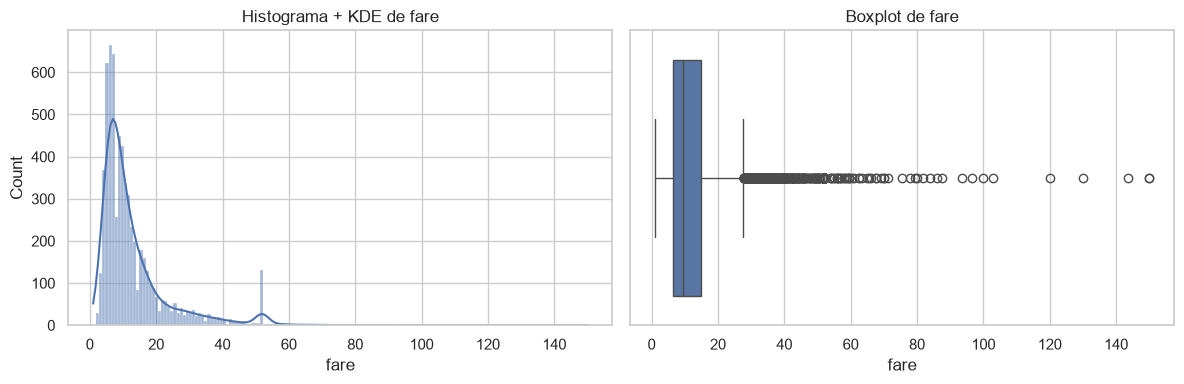

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(fare, kde=True, ax=axes[0])
axes[0].set_title("Histograma + KDE de fare")
sns.boxplot(x=fare, ax=axes[1])
axes[1].set_title("Boxplot de fare")
plt.tight_layout()
plt.show()

### Evaluación de normalidad de `fare`

Asimetría: 3.22
Curtosis (exceso): 17.74
Shapiro-Wilk p-valor: 4.81e-76


C:\Users\nicol\projects\esp_estadistica_202607\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6384.
  res = hypotest_fun_out(*samples, **kwds)


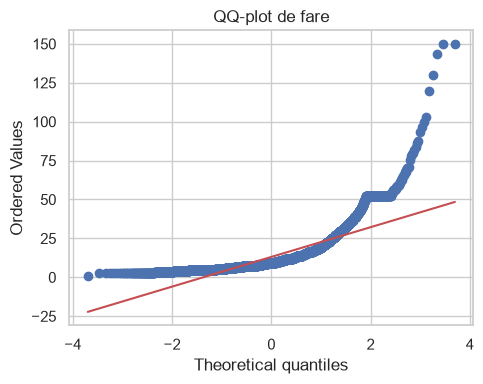

In [17]:
fare_skew = stats.skew(fare)
fare_kurtosis = stats.kurtosis(fare)
_, fare_p_value = stats.shapiro(fare)

print(f"Asimetría: {fare_skew:.2f}")
print(f"Curtosis (exceso): {fare_kurtosis:.2f}")
print(f"Shapiro-Wilk p-valor: {fare_p_value:.2e}")

fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(fare, dist="norm", plot=ax)
ax.set_title("QQ-plot de fare")
plt.tight_layout()
plt.show()

La asimetría (~3.2) es mucho más pronunciada que la de `horsepower` en la sesión 3 (~1.1), y el QQ-plot se separa claramente de la línea de normalidad en la cola superior. Shapiro-Wilk rechaza normalidad con un p-valor extremadamente bajo (además, con n > 5000 scipy ya advierte que el p-valor puede no ser preciso — con una muestra así de grande casi cualquier desviación por pequeña que sea resulta "significativa", por eso conviene mirar la forma real en el histograma/QQ-plot y no solo el p-valor). Esto confirma que la regla del IQR (no la de z-score, que asume normalidad) es la adecuada para detectar atípicos en `fare`.

## 5. Relación con la variable target (`payment`)

Cerramos comparando las variables numéricas y categóricas frente al método de pago.

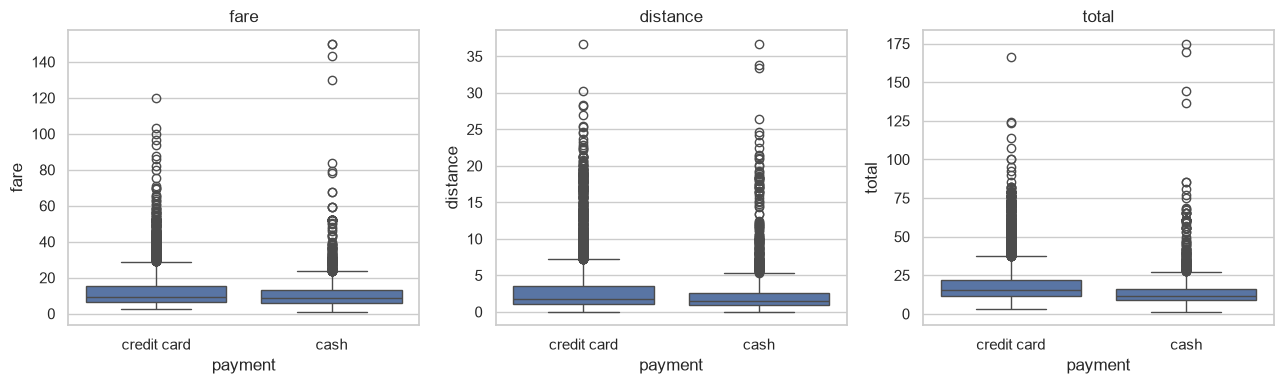

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, columna in zip(axes, ["fare", "distance", "total"]):
    sns.boxplot(data=taxis_limpio, x="payment", y=columna, ax=ax)
    ax.set_title(columna)
plt.tight_layout()
plt.show()

In [19]:
taxis_limpio.groupby("payment")[["fare", "distance", "total"]].agg(["mean", "median"])

fare        distance          total       
               mean median     mean median    mean median
payment                                                  
cash         11.603    8.5    2.544   1.44  14.689  11.30
credit card  13.698    9.5    3.224   1.73  20.079  15.35

En promedio, los viajes pagados con tarjeta tienen `fare`, `distance` y `total` algo mayores que los pagados en efectivo — consistente con lo visto en la sección 3 (Queens, con viajes más largos, también tiene mayor proporción de tarjeta).

In [20]:
print(taxis_limpio.groupby("payment")["tip"].apply(lambda serie: (serie == 0).mean()))

payment
cash           1.000
credit card    0.099
Name: tip, dtype: float64


**Ojo con esta:** el 100% de los pagos en efectivo tienen `tip == 0`. No es que nadie dé propina en efectivo — es que el sistema del taxímetro **no registra** propinas en efectivo, solo las que van por tarjeta. Por eso **no comparamos `tip` por `payment`** directamente: sería comparar "propina real" contra "propina no registrada", no una diferencia de comportamiento. Es el mismo tipo de trampa de interpretación que vimos con el IC de `tip_pct` en la sesión 1: siempre hay que entender cómo se capturó una variable antes de interpretarla.

In [21]:
pd.crosstab(taxis_limpio["color"], taxis_limpio["payment"], normalize="index") * 100

payment,cash,credit card
color,,
green,40.947,59.053
yellow,26.090,73.910


Los taxis verdes tienen una proporción de pagos en efectivo notablemente mayor (~41%) que los amarillos (~26%) — coherente con que los verdes operan en zonas fuera del centro (Queens, Bronx, Brooklyn), donde ya vimos más pago en efectivo.

## Cierre

**Ideas clave:**

- La limpieza de datos no es una receta única: la misma anomalía puede requerir eliminar, imputar con una categoría explícita, imputar con un estadístico (moda), o simplemente documentarse sin corregir, dependiendo de qué tan defendible es cada decisión.
- Las variables cualitativas (`payment`, `color`, `pickup_borough`) se describen con tablas de frecuencia, gráficos de barras y tablas de contingencia; relacionarlas con una numérica (boxplot por grupo) ya anticipa patrones sin necesidad de una prueba formal.
- `fare` está fuertemente sesgada a la derecha (asimetría ~3.2) y no es normal — la regla de atípicos por IQR es la adecuada aquí, no la de z-score.
- El hallazgo más importante del taller no es estadístico sino de **captura de datos**: `tip` en efectivo siempre es 0 por diseño del sistema, no por comportamiento — ignorar esto llevaría a una conclusión de negocio equivocada.
- Los viajes pagados con tarjeta tienden a ser más largos/caros, y las zonas fuera de Manhattan (especialmente Queens) muestran mayor uso de efectivo — información directamente accionable para la campaña planteada al inicio.

**Qué queda fuera a propósito:** este taller se queda en estadística *descriptiva*. No se prueba si estas diferencias son estadísticamente significativas (eso requiere pruebas de hipótesis) ni se cuantifica la fuerza de la asociación con un número formal (Cramér's V, eta-cuadrado) — eso es contenido de la sesión 6 en adelante.